# Diabetes Risk Prediction using CatBoost

Author: Kevin J.

Project Type: Machine Learning Classification  

Metric: ROC-AUC

This project predicts diabetes risk using health, lifestyle, and demographic data.

## Project Motivation

Diabetes is a major global health issue. Early identification of high-risk individuals may support prevention and intervention strategies.

This project explores whether machine learning can predict diabetes diagnosis using structured tabular data.

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 



## Dataset Overview

The dataset contains demographic, lifestyle, and health-related variables.

Target Variable:
- diagnosed_diabetes (0 = No, 1 = Yes)

In [22]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")


In [ ]:
## Read the data.
train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [4]:
train.shape, test.shape

((700000, 26), (300000, 25))

In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                          7

In [23]:
## Checking target distribution
train["diagnosed_diabetes"].value_counts(normalize = True)

diagnosed_diabetes
1.0    0.623296
0.0    0.376704
Name: proportion, dtype: float64

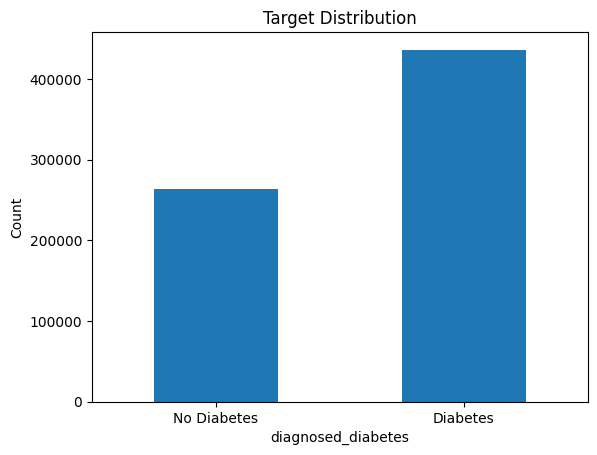

In [31]:

train["diagnosed_diabetes"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], ["No Diabetes", "Diabetes"], rotation=0)
plt.ylabel("Count")
plt.title("Target Distribution")
plt.savefig("../images/target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:**
The target variable is moderately imbalanced, with diabetic cases appearing more frequently than non-diabetic cases.
This was later addressed using Stratified K-Fold Cross Validation.

In [25]:
## Checking missing values
train.isnull().sum().sort_values(ascending=False)

id                                    0
age                                   0
cardiovascular_history                0
hypertension_history                  0
family_history_diabetes               0
employment_status                     0
smoking_status                        0
income_level                          0
education_level                       0
ethnicity                             0
gender                                0
triglycerides                         0
ldl_cholesterol                       0
hdl_cholesterol                       0
cholesterol_total                     0
heart_rate                            0
diastolic_bp                          0
systolic_bp                           0
waist_to_hip_ratio                    0
bmi                                   0
screen_time_hours_per_day             0
sleep_hours_per_day                   0
diet_score                            0
physical_activity_minutes_per_week    0
alcohol_consumption_per_week          0


## Feature and Target Definition

Before modeling, we will separate the dataset into:

- Features (`X`): input variables used to predict diabetes risk;
- Target (`y`): the outcome variable, `diagnosed_diabetes`.

The `id` column is removed because it is only an identifier and does not provide predictive information.

In [28]:
# Find out X and Y
X = train.drop(columns=["diagnosed_diabetes", "id"])
y = train["diagnosed_diabetes"]

# Split!
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_test = test.drop(columns=["id"])

# Find categorical columns
cat_features = X.select_dtypes(include=["object", "str"]).columns.tolist()


## 1. Baseline Model + Gradient Boosting (CatBoost Classifier)

In [20]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric="AUC",
    verbose=False
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_features
)


val_preds = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_preds)
print("Validation AUC:", auc)

Validation AUC: 0.7208808857312505


### Baseline Result Interpretation

- The baseline CatBoost model showed a validation AUC of approximately **0.72088** using a single train-validation split. 

- This result indicates that the model has meaningful predictive power and performs clearly better than random guessing.

- This baseline provides a **reference point** for later different experiments, including stratified K-fold cross-validation, feature importance analysis, ablation study, and feature engineering.



## 2. Refinement: Stratified K-Fold Cross Validation

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        eval_metric="AUC",
        verbose=False
    )

    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_features
    )

    # validation prediction
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

   

In [11]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y, oof_preds)
print("CV AUC:", auc)

CV AUC: 0.7209262686898092


###     Stratified K-Fold Result Interpretation:
- From this method, we can find that the AUC score is **0.72093**, which is very close to the single split baseline.

- The Stratified K-Fold approach produced a **slightly more stable** and reliable AUC estimate compared to the single train-validation split. This suggests that cross-validation can **reduce** evaluation variance and provide a more robust estimate of model performance.

- The baseline performance is relatively stable and not strongly dependent on one random train-validation split. Stratified K-Fold also helps preserve the target class distribution across folds.

## 3. Ablation Study (With SKF Again)

To understand feature dependence, we remove the strongest predictors and observe performance changes.

In [12]:
feature_importance = model.get_feature_importance()

fi_df = pd.DataFrame({
    "feature": X.columns,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)

print(fi_df.head(15))

                               feature  importance
21             family_history_diabetes   36.452993
2   physical_activity_minutes_per_week   33.957606
0                                  age   12.599111
14                       triglycerides    6.090543
6                                  bmi    2.790388
13                     ldl_cholesterol    1.583129
3                           diet_score    1.040391
10                          heart_rate    0.944201
11                   cholesterol_total    0.895638
12                     hdl_cholesterol    0.858390
8                          systolic_bp    0.729648
7                   waist_to_hip_ratio    0.671625
5            screen_time_hours_per_day    0.426678
9                         diastolic_bp    0.236059
1         alcohol_consumption_per_week    0.136115


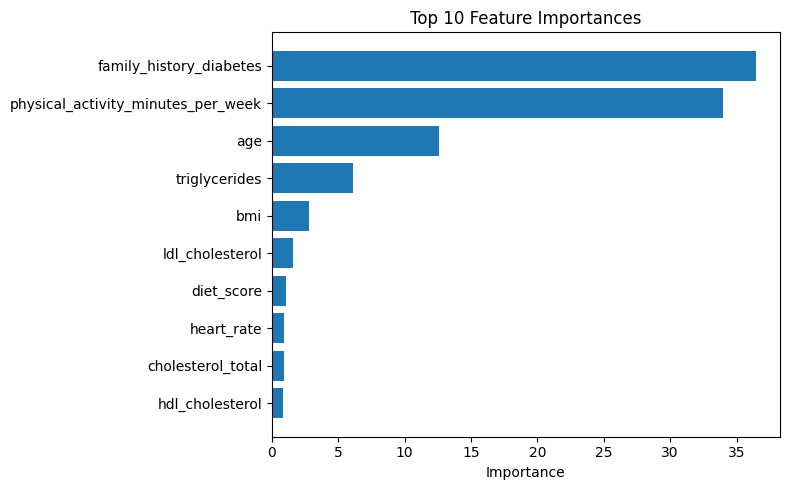

In [30]:
top_features = fi_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

From the graph, we can see that **Family history of diabetes** and **physical activity** were the strongest predictors in the model.

In [ ]:
## We will drop the most impact features (Family history of diabetes and physical activity minutes per week) 
# and see how the model performs without them:

X_drop = X.drop(columns=[
    "family_history_diabetes",
    "physical_activity_minutes_per_week"
])

X_test_drop = X_test.drop(columns=[
    "family_history_diabetes",
    "physical_activity_minutes_per_week"
])


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X_drop))

# categorical columns
cat_features_drop = [col for col in cat_features if col in X_drop.columns]

for fold, (train_idx, val_idx) in enumerate(skf.split(X_drop, y)):

    X_train, X_val = X_drop.iloc[train_idx], X_drop.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        eval_metric="AUC",
        verbose=False
    )

    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_features_drop
    )

    # validation prediction
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]



auc = roc_auc_score(y, oof_preds)
print("CV AUC after dropping 2 strong features:", auc)

CV AUC after dropping 2 strong features: 0.6301782941106848


### Ablation Result Interpretation:
- After removing the two strongest predictors, **family_history_diabetes** and **physical_activity_minutes_per_week**, the CV AUC dropped from approximately 0.721 to **0.63018**.

- This large performance decline confirms that the model relies **heavily** on these two features. It also suggests that family history and physical activity contain substantial predictive signal for diabetes risk classification.

## 4. Feature Engineering

We test whether manually created interaction and ratio features can improve model performance.

In [ ]:
# age * bmi interaction
X["age_bmi"] = X["age"] * X["bmi"]
X_test["age_bmi"] = X_test["age"] * X_test["bmi"]

# ratio (For medical use)
X["trig_hdl_ratio"] = X["triglycerides"] / (X["hdl_cholesterol"] + 1)
X_test["trig_hdl_ratio"] = X_test["triglycerides"] / (X_test["hdl_cholesterol"] + 1)

# lifestyle (Easier and Efficient)
X["lifestyle_score"] = X["diet_score"] + X["physical_activity_minutes_per_week"] - X["screen_time_hours_per_day"]
X_test["lifestyle_score"] = X_test["diet_score"] + X_test["physical_activity_minutes_per_week"] - X_test["screen_time_hours_per_day"]

In [ ]:
skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
cat_features_updated = [col for col in cat_features if col in X.columns]

for fold, (train_idx, val_idx) in enumerate(skf2.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        eval_metric="AUC",
        verbose=False
    )

    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_features_updated
    )

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
   

auc = roc_auc_score(y, oof_preds)
print("CV AUC with engineered features:", auc)

CV AUC with engineered features: 0.7204567282666595


### Feature Engineering Results Interpretation：

- The engineered feature model achieved a CV AUC of approximately 0.72046, which **did not** improve over the original Stratified K-Fold CatBoost model.

- This suggests that **CatBoost** was already able to capture much of the useful nonlinear structure from the original features, and the manually engineered features **did not** provide additional predictive lift in this experiment.

## Model Comparison

| Experiment | AUC |
|---|---:|
| Baseline CatBoost Single Split | 0.72088 |
| Stratified K-Fold CatBoost | 0.72093 |
| Ablation: Drop Top 2 Features | 0.63018 |
| Feature Engineering | 0.72046 |


- The Stratified K-Fold CatBoost model provided the most stable performance, while the ablation study showed that removing the strongest predictors caused a substantial decline in AUC. Feature engineering did not improve performance, suggesting that CatBoost already captured useful relationships in the original feature set.

## Final Conclusion

This project aimed to evaluate whether machine learning can effectively predict diabetes risk using structured data, and whether additional feature engineering improves performance.

- **CatBoost** performed strongly on mixed tabular data.
- **Family history and physical activity** were the most influential predictors.
- Removing key predictors significantly **reduced** model performance.
- Manual feature engineering provided **limited** improvement.

This suggests that strong baseline models can already capture substantial nonlinear structure in structured healthcare data.

## What I Learned

- Cross-validation provides a more reliable estimate than a single split.
- Feature importance helps identify which variables drive predictions.
- Feature engineering does not always improve performance when using strong models like CatBoost.